All libraries imported successfully!
Dataset shape: (768, 9)
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
Rows: 768, Columns: 9
Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
Zero (Missing) Values:
  Glucose: 5 zeros (0.7%)
  BloodPressure: 35 zeros (4.6%)
  SkinThickness: 227 zeros (29.6%)
  Insulin: 374 zeros (48.7%)
  BMI: 11 zeros (1.4%)


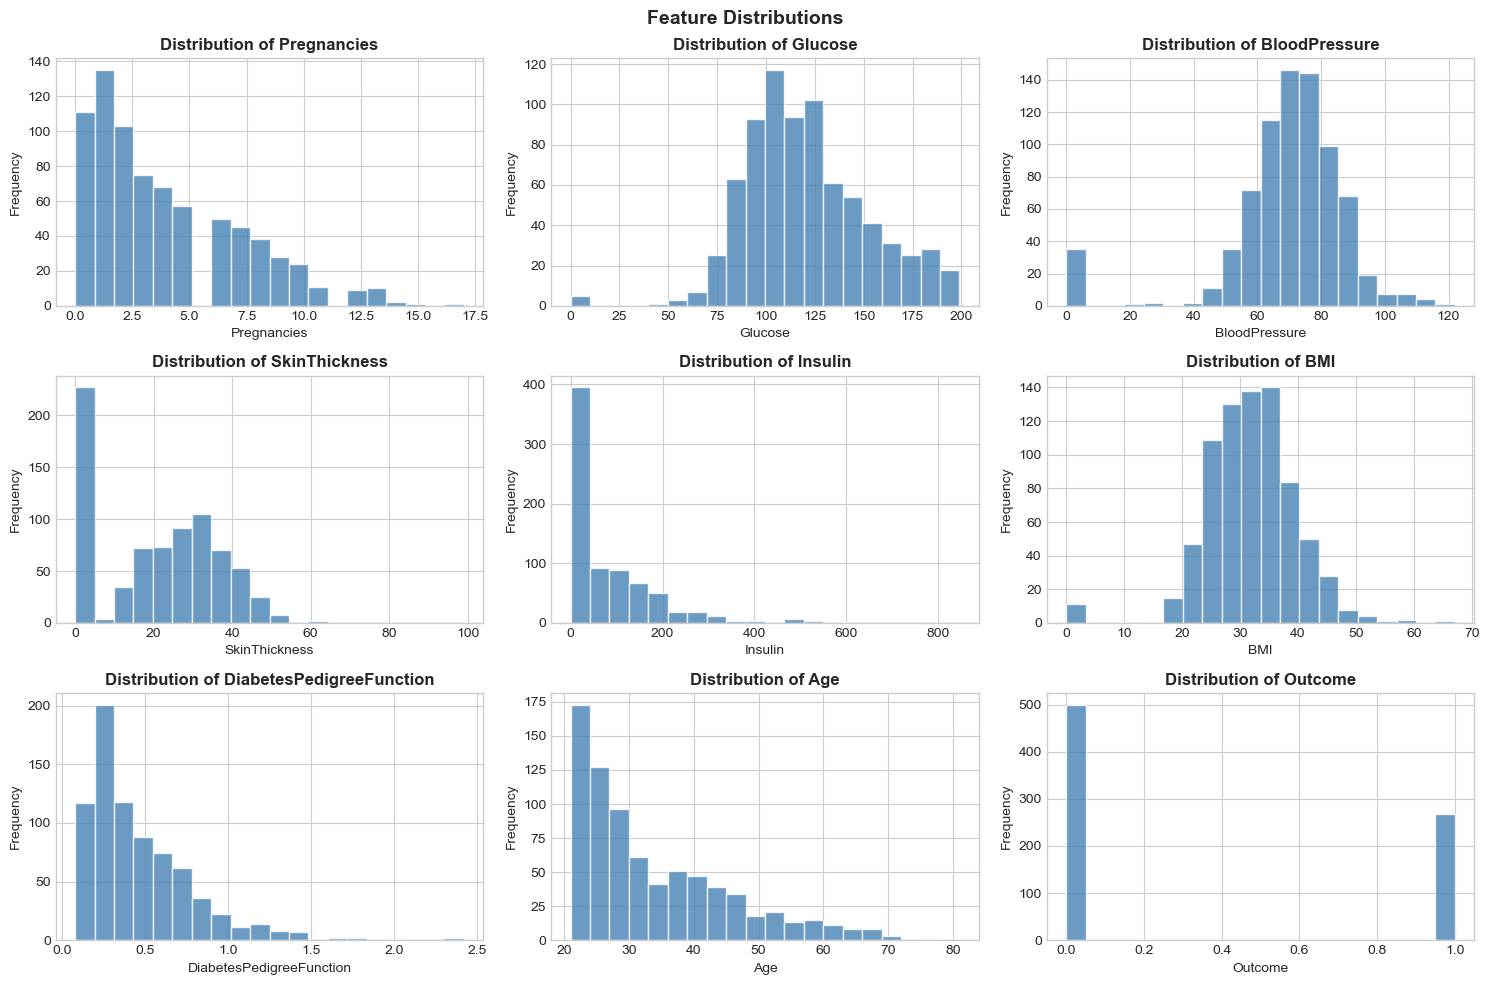

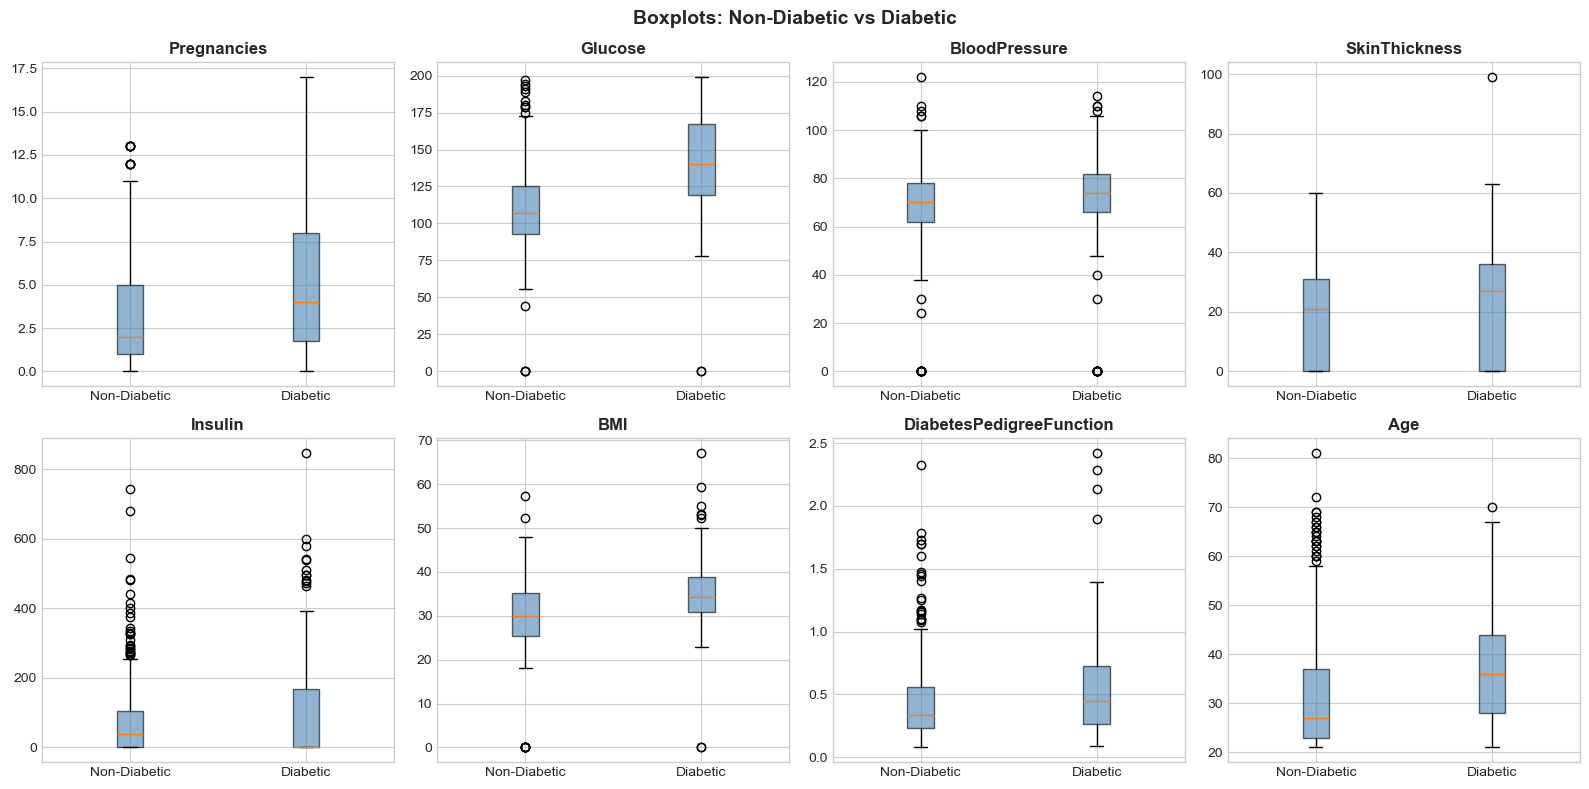

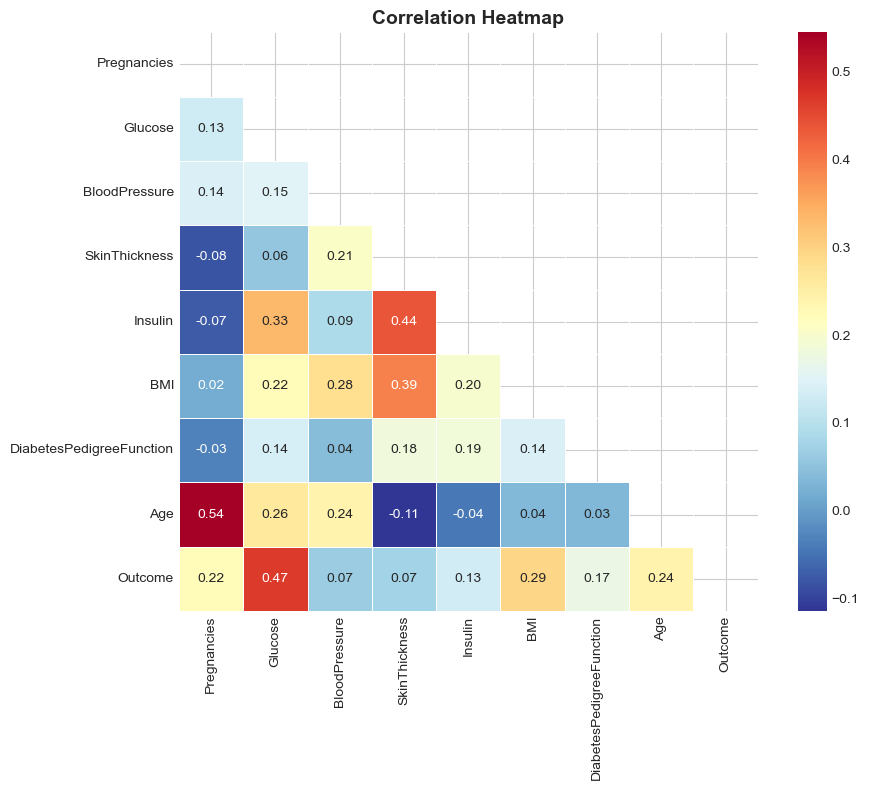

Correlations with Outcome:
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64
Outliers (Z-score > 3):
  Pregnancies: 4 outliers
  Glucose: 5 outliers
  BloodPressure: 35 outliers
  SkinThickness: 1 outliers
  Insulin: 18 outliers
  BMI: 14 outliers
  DiabetesPedigreeFunction: 11 outliers
  Age: 5 outliers
Train: 614, Test: 154
Logistic Regression
  Accuracy: 0.7078 | Recall: 0.5000 | F1: 0.5455 | AUC: 0.8152
SVM
  Accuracy: 0.7338 | Recall: 0.5370 | F1: 0.5859 | AUC: 0.7939
Random Forest
  Accuracy: 0.7597 | Recall: 0.5926 | F1: 0.6337 | AUC: 0.8200


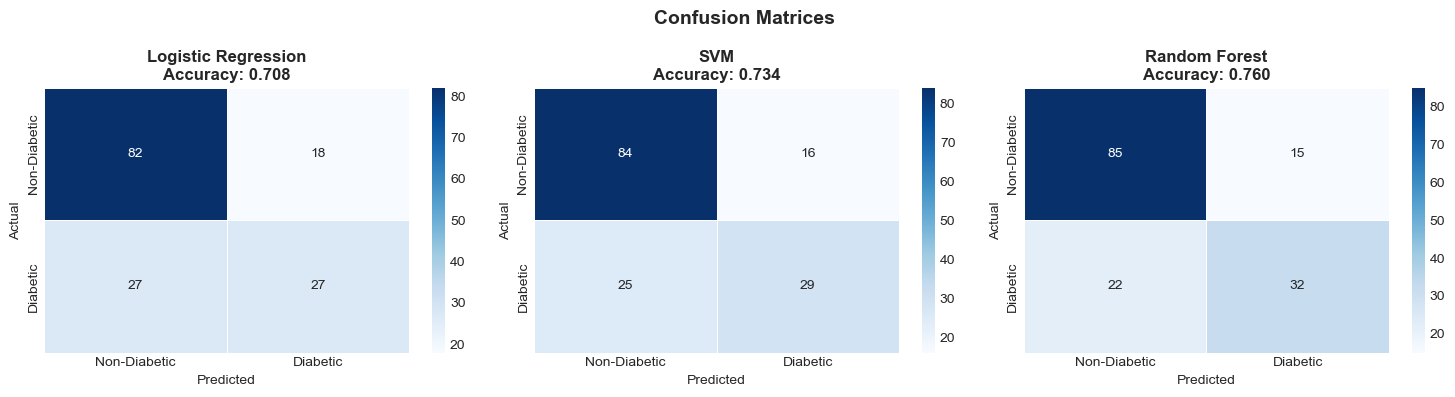

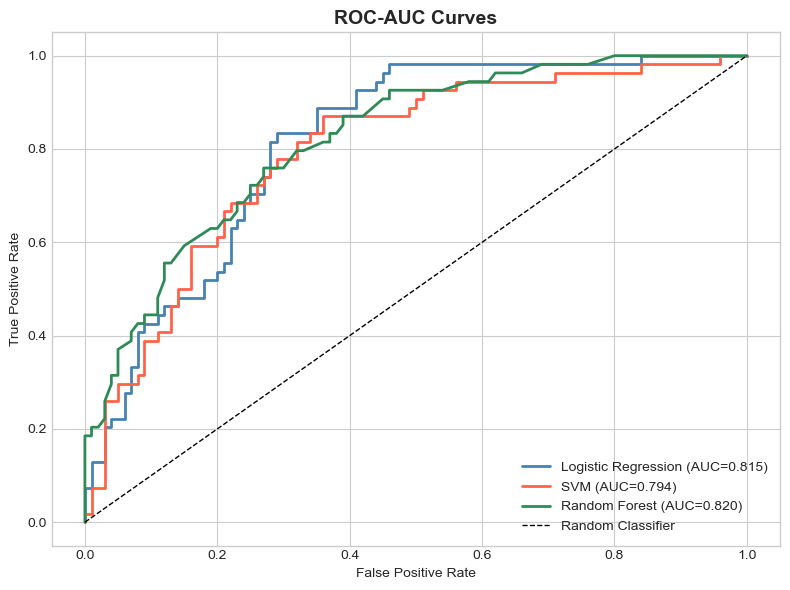

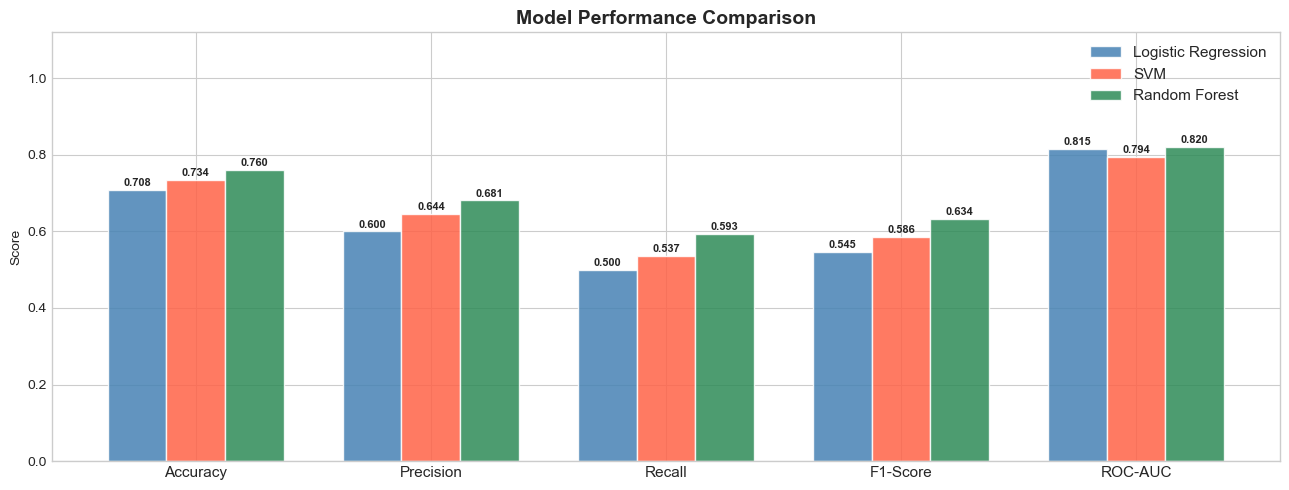

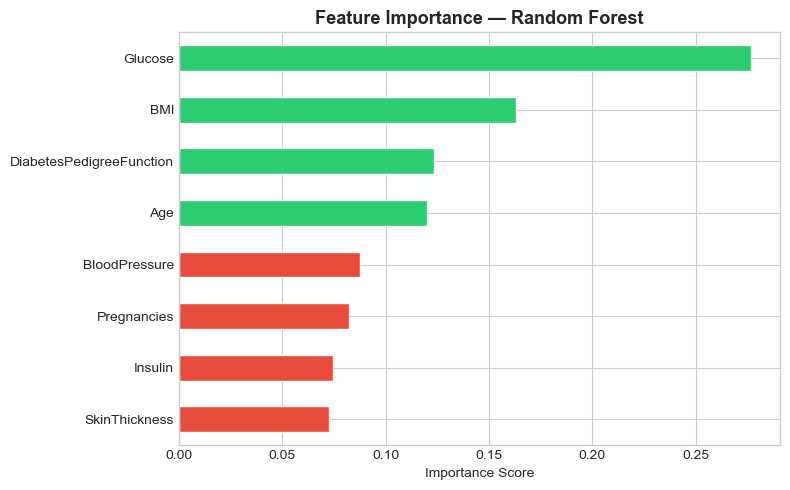

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score, roc_curve)
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
print("All libraries imported successfully!")

# ===== Next Cell =====

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ["Pregnancies","Glucose","BloodPressure","SkinThickness",
           "Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]
df = pd.read_csv(url, names=columns)
print(f"Dataset shape: {df.shape}")
df.head()

# ===== Next Cell =====

print(df.dtypes)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Class distribution:\n{df['Outcome'].value_counts()}")  # FIX: changed "Outcome" to 'Outcome' inside f-string

# ===== Next Cell =====

df.describe().round(2)

# ===== Next Cell =====

zero_cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
print("Zero (Missing) Values:")
for col in zero_cols:
    z = (df[col] == 0).sum()
    print(f"  {col}: {z} zeros ({z/len(df)*100:.1f}%)")

# ===== Next Cell =====

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=20, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(f"Distribution of {col}", fontweight="bold")
    axes[i].set_xlabel(col); axes[i].set_ylabel("Frequency")
plt.suptitle("Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("histograms.png", dpi=150, bbox_inches="tight"); plt.show()

# ===== Next Cell =====

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
features = [c for c in df.columns if c != "Outcome"]
for i, col in enumerate(features):
    axes[i].boxplot([df[df["Outcome"]==0][col], df[df["Outcome"]==1][col]],
                    labels=["Non-Diabetic","Diabetic"], patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.6))
    axes[i].set_title(col, fontweight="bold")
plt.suptitle("Boxplots: Non-Diabetic vs Diabetic", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("boxplots.png", dpi=150, bbox_inches="tight"); plt.show()

# ===== Next Cell =====

fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlBu_r",
            mask=mask, ax=ax, square=True, linewidths=0.5)
ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
print("Correlations with Outcome:")
print(corr["Outcome"].sort_values(ascending=False)[1:])

# ===== Next Cell =====

print("Outliers (Z-score > 3):")
features = [c for c in df.columns if c != "Outcome"]
for col in features:
    z = np.abs(stats.zscore(df[col]))
    print(f"  {col}: {(z > 3).sum()} outliers")

# ===== Next Cell =====

df_clean = df.copy()
zero_cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in zero_cols:
    df_clean[col] = df_clean[col].replace(0, df_clean[col].median())

X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# ===== Next Cell =====

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    results[name] = {
        "model": model, "y_pred": y_pred, "y_prob": y_prob,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }
    print(f"{name}")  # FIX: indented inside the for loop
    print(f"  Accuracy: {results[name]['accuracy']:.4f} | Recall: {results[name]['recall']:.4f} | F1: {results[name]['f1']:.4f} | AUC: {results[name]['roc_auc']:.4f}")

# ===== Next Cell =====

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=["Non-Diabetic","Diabetic"],
                yticklabels=["Non-Diabetic","Diabetic"], linewidths=0.5)
    ax.set_title(f"{name}\nAccuracy: {r['accuracy']:.3f}", fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight"); plt.show()

# ===== Next Cell =====

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["steelblue", "tomato", "seagreen"]
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})", color=color, lw=2)
ax.plot([0,1],[0,1], "k--", lw=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-AUC Curves", fontsize=14, fontweight="bold")
ax.legend(loc="lower right"); plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight"); plt.show()

# ===== Next Cell =====

metrics = ["accuracy","precision","recall","f1","roc_auc"]
labels = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
model_names = list(results.keys())
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(labels)); w = 0.25
for i, (name, color) in enumerate(zip(model_names, ["steelblue","tomato","seagreen"])):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i*w, vals, w, label=name, color=color, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_xticks(x + w); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.12); ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold")
ax.legend(fontsize=11); plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

# ===== Next Cell =====

rf = results["Random Forest"]["model"]
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
colors_imp = ["#2ecc71" if v >= feat_imp.median() else "#e74c3c" for v in feat_imp]
feat_imp.plot(kind="barh", ax=ax, color=colors_imp, edgecolor="white")
ax.set_title("Feature Importance — Random Forest", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout(); plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight"); plt.show()